# Experiment 1 — Loan Prediction (Classification)

**Course**   : ICS1512 — Machine Learning Laboratory, Semester 5  
**Roll No**  : 3122247001061  
**Dataset**  : Loan Prediction Dataset (Analytics Vidhya)  
**Aim**      : Build and evaluate classification models to predict whether a loan application will be Approved (Y) or Rejected (N).

---

**Pipeline**
```
Load Dataset → EDA → Preprocessing → Feature Selection
→ Train-Test Split → Model Training → Evaluation → Save Outputs
```

## Cell 1 — Setup: Imports & Configuration

In [1]:
import sys
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Add ../src/ to path so we can import our modules
SRC_PATH = os.path.abspath(os.path.join("..", "src"))
if SRC_PATH not in sys.path:
    sys.path.insert(0, SRC_PATH)

from eda              import run_eda
from preprocessing    import preprocess
from feature_selection import select_features
from models           import classification_model
from evaluation       import classification_metrics

# ---------------------------------------------------------------------------
# CONFIGURATION — change these values to adapt to a different experiment
# ---------------------------------------------------------------------------
DATASET_PATH     = os.path.join("..", "dataset", "loan_prediction", "train.csv")
TARGET_COLUMN    = "Loan_Status"       # column the model will predict
EXCLUDE_COLUMNS  = ["Loan_ID"]         # ID columns — keep in data but don't use as features
FIGURES_PATH     = os.path.abspath(os.path.join("..", "figures"))
OUTPUT_PATH      = os.path.abspath(os.path.join("..", "output"))

# Preprocessing choices
MISSING_STRATEGY = "mean"              # options: "mean", "median", "mode", "drop"
ENCODING         = "label"             # options: "label", "onehot", None
SCALING          = None                # options: "standard", "minmax", None
                                       # None is fine for Decision Tree / Naive Bayes

# Feature selection choices
FS_METHOD        = "chi2"              # options: "chi2", "anova", "mutual_info"
FS_K             = 8                   # number of top features to keep

# Model choice
MODEL_NAME       = "decision_tree"     # options: knn, decision_tree, naive_bayes,
                                       #          logistic_regression, svm, random_forest

# Train-test split
TEST_SIZE        = 0.20                # 80% train, 20% test
RANDOM_STATE     = 42                  # fixed seed for reproducibility

print("Configuration ready.")

Configuration ready.


## Cell 2 — Load Dataset

In [2]:
df = pd.read_csv(DATASET_PATH)

print(f"Shape  : {df.shape[0]} rows × {df.shape[1]} columns")
print(f"Target : '{TARGET_COLUMN}'  →  {df[TARGET_COLUMN].unique().tolist()}")

df.head()

Shape  : 614 rows × 13 columns
Target : 'Loan_Status'  →  ['Y', 'N']


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


## Cell 3 — Exploratory Data Analysis (EDA)

1. DATASET OVERVIEW
  Rows    : 614
  Columns : 13

           Column   Dtype  Non-Null
          Loan_ID  object       614
           Gender  object       601
          Married  object       611
       Dependents  object       599
        Education  object       614
    Self_Employed  object       582
  ApplicantIncome   int64       614
CoapplicantIncome float64       614
       LoanAmount float64       592
 Loan_Amount_Term float64       600
   Credit_History float64       564
    Property_Area  object       614
      Loan_Status  object       614

2. MISSING VALUES
                  Missing Count  Missing %
Gender                       13       2.12
Married                       3       0.49
Dependents                   15       2.44
Self_Employed                32       5.21
LoanAmount                   22       3.58
Loan_Amount_Term             14       2.28
Credit_History               50       8.14

3. DUPLICATE ROWS
  Duplicate rows : 0  (0.0%)

4. SUMMARY STATISTICS
  Numerica

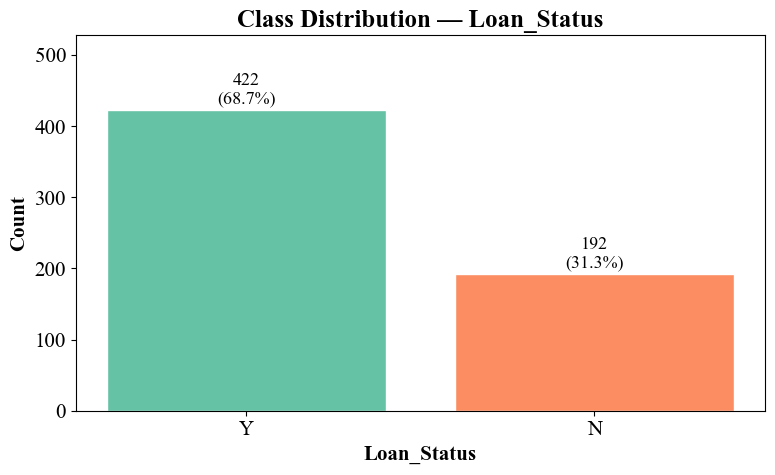

6. FEATURE DISTRIBUTIONS (Histograms)


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


  [Saved] d:\Visual_Studio_Code\3122247001061\sem_5\labs\exp_01\figures\histograms.eps



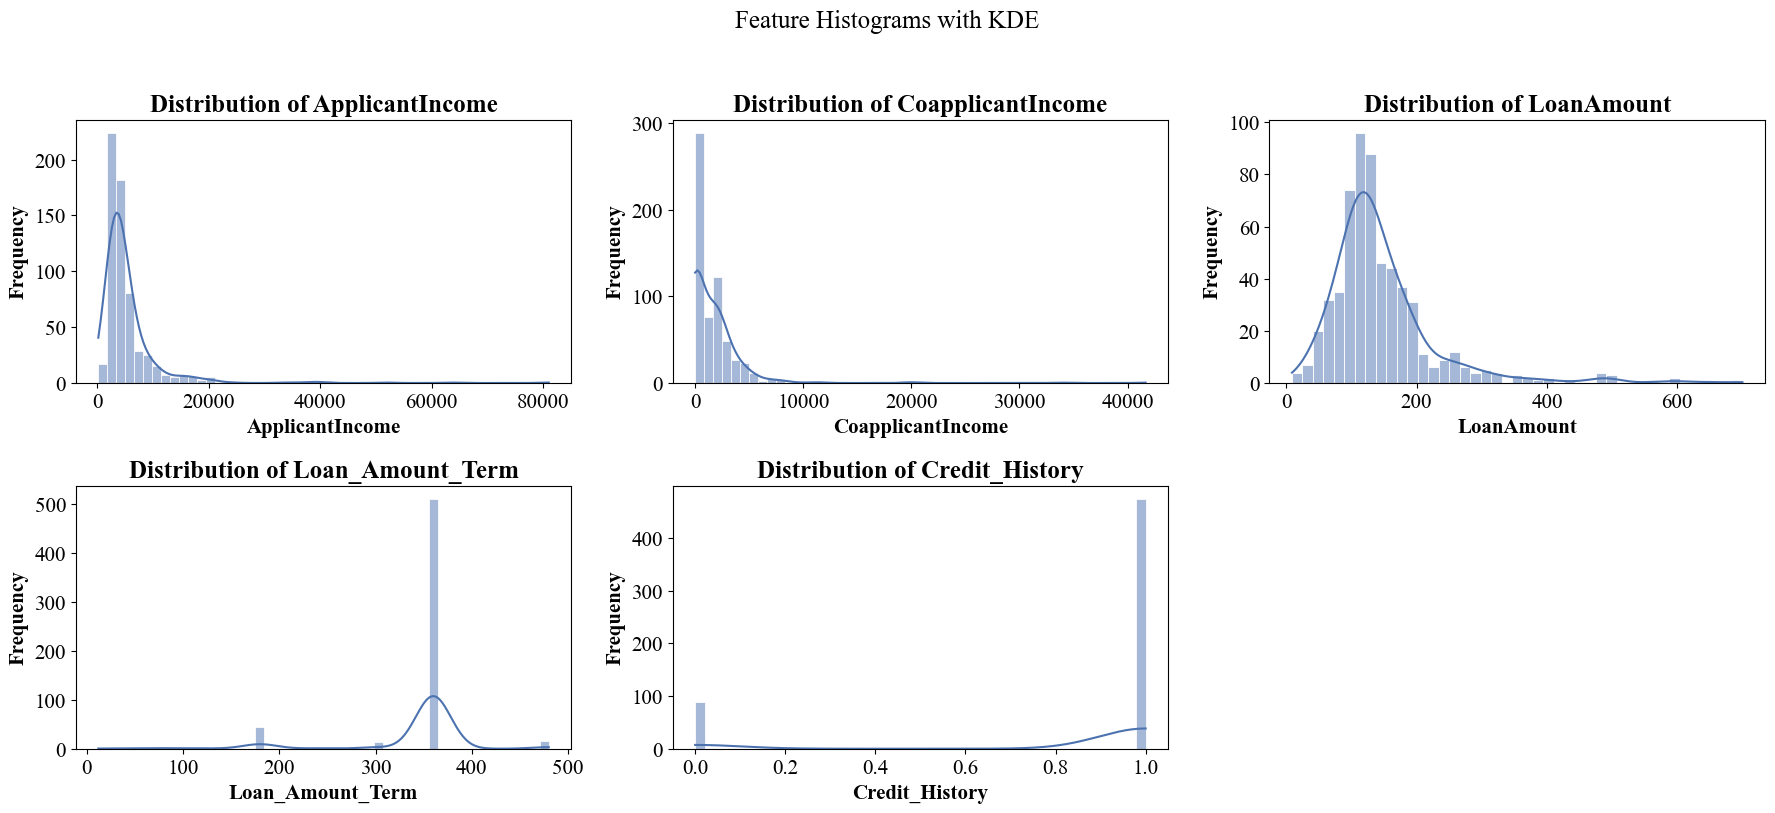

7. CORRELATION HEATMAP
  [Saved] d:\Visual_Studio_Code\3122247001061\sem_5\labs\exp_01\figures\correlation_heatmap.eps



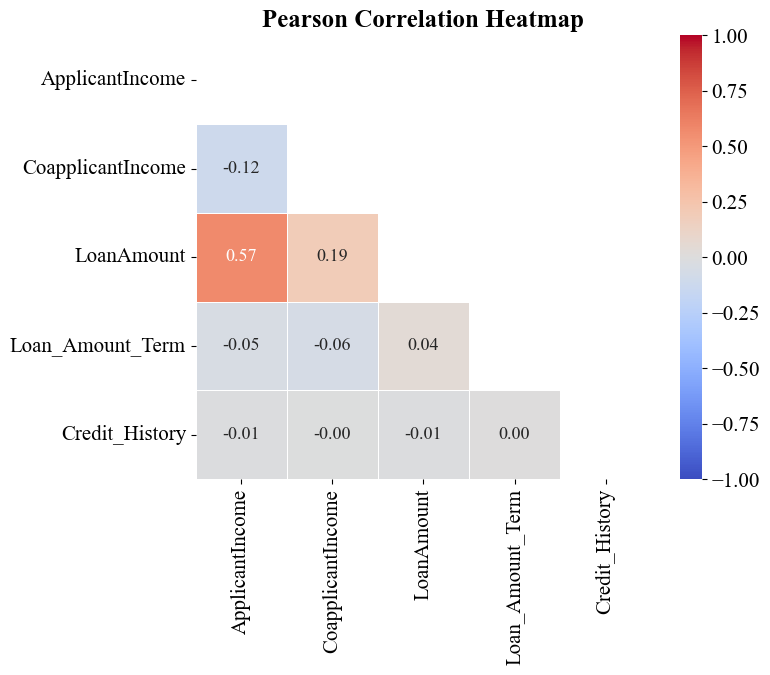

In [3]:
eda_results = run_eda(
    df            = df,
    target_column = TARGET_COLUMN,
    figures_path  = FIGURES_PATH,
)

## Cell 4 — Preprocessing

In [4]:
clean_df = preprocess(
    df               = df,
    target_column    = TARGET_COLUMN,
    exclude_columns  = EXCLUDE_COLUMNS,
    missing_strategy = MISSING_STRATEGY,
    encoding         = ENCODING,
    scaling          = SCALING,
)

clean_df.head()

STEP 1: Drop Duplicates
  Rows before : 614
  Rows after  : 614  (0 duplicates removed)

STEP 2: Handle Missing Values  (strategy: 'mean')
  'LoanAmount' → filled with mean = 146.4122
  'Loan_Amount_Term' → filled with mean = 342.0000
  'Credit_History' → filled with mean = 0.8422
  'Gender' → filled with mode = 'Male'
  'Married' → filled with mode = 'Yes'
  'Dependents' → filled with mode = '0'
  'Self_Employed' → filled with mode = 'No'

STEP 3: Encode Categorical Features  (method: 'label')
  'Gender' → {'Female': 0, 'Male': 1}
  'Married' → {'No': 0, 'Yes': 1}
  'Dependents' → {'0': 0, '1': 1, '2': 2, '3+': 3}
  'Education' → {'Graduate': 0, 'Not Graduate': 1}
  'Self_Employed' → {'No': 0, 'Yes': 1}
  'Property_Area' → {'Rural': 0, 'Semiurban': 1, 'Urban': 2}

STEP 4: Scale Numerical Features  (method: 'None')
  Skipped (scaling=None).
  Tip: Tree-based models (Decision Tree, Random Forest) don't need scaling.

PREPROCESSING COMPLETE
  Output shape : 614 rows × 13 columns
  NaN re

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,1,0,0,0,0,5849,0.0,146.412162,360.0,1.0,2,Y
1,LP001003,1,1,1,0,0,4583,1508.0,128.000000,360.0,1.0,0,N
2,LP001005,1,1,0,0,1,3000,0.0,66.000000,360.0,1.0,2,Y
3,LP001006,1,1,0,1,0,2583,2358.0,120.000000,360.0,1.0,2,Y
4,LP001008,1,0,0,0,0,6000,0.0,141.000000,360.0,1.0,2,Y


## Cell 5 — Encode Target Column

`preprocess()` deliberately protects the target column from encoding.
Feature selection functions (chi2, etc.) require a **numeric** target, so we encode it here manually.

In [5]:
le = LabelEncoder()
clean_df[TARGET_COLUMN] = le.fit_transform(clean_df[TARGET_COLUMN])

# Print the encoding so it can be recorded in observations
mapping = dict(zip(le.classes_, le.transform(le.classes_).tolist()))
print(f"Target encoding: {mapping}")
# e.g. {'N': 0, 'Y': 1}  →  N = loan rejected, Y = loan approved

Target encoding: {'N': 0, 'Y': 1}


## Cell 6 — Feature Selection

In [6]:
selected_features, scores_df = select_features(
    df              = clean_df,
    target_column   = TARGET_COLUMN,
    method          = FS_METHOD,
    k               = FS_K,
    exclude_columns = EXCLUDE_COLUMNS,
)

# Build X (features) and y (target) from the selected columns
X = clean_df[selected_features]
y = clean_df[TARGET_COLUMN]

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")


  FEATURE SELECTION
  Method           : chi2
  Total features   : 11
  Features selected: 8

 Rank           Feature      Score
    1 CoapplicantIncome 11342.0416
    2   ApplicantIncome    93.9050
    3        LoanAmount    39.2115
    4    Credit_History    25.9989
    5         Education     3.5405
    6  Loan_Amount_Term     3.2673
    7           Married     1.7824
    8     Property_Area     0.3778
    9        Dependents     0.0860
   10            Gender     0.0362
   11     Self_Employed     0.0073

  Selected: ['CoapplicantIncome', 'ApplicantIncome', 'LoanAmount', 'Credit_History', 'Education', 'Loan_Amount_Term', 'Married', 'Property_Area']

X shape: (614, 8)
y shape: (614,)


## Cell 7 — Train-Test Split

Kept **visible in the notebook** by design — this is a core ML step the professor checks.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = TEST_SIZE,
    random_state = RANDOM_STATE,
    stratify     = y,            # keep class proportions in both splits
)

print(f"Training set : {X_train.shape[0]} samples")
print(f"Test set     : {X_test.shape[0]} samples")

Training set : 491 samples
Test set     : 123 samples


## Cell 8 — Model Training

In [8]:
model, y_pred, y_prob, train_time, pred_time = classification_model(
    X_train    = X_train,
    y_train    = y_train,
    X_test     = X_test,
    model_name = MODEL_NAME,
)


  CLASSIFICATION MODEL: DecisionTreeClassifier
  Training samples  : 491
  Test samples      : 123
  Training time     : 0.0210 s
  Prediction time   : 0.0026 s



## Cell 9 — Evaluation


  CLASSIFICATION EVALUATION RESULTS
   Metric  Value
 Accuracy 0.7805
Precision 0.7821
   Recall 0.7805
 F1 Score 0.7813
  ROC-AUC 0.7466

  Confusion Matrix:

    Predicted     Rejected (N)  Approved (Y)
    Actual                                  
    Rejected (N)            25            13
    Approved (Y)            14            71

  Classification Report:
              precision    recall  f1-score   support

Rejected (N)       0.64      0.66      0.65        38
Approved (Y)       0.85      0.84      0.84        85

    accuracy                           0.78       123
   macro avg       0.74      0.75      0.74       123
weighted avg       0.78      0.78      0.78       123

  Saved: d:\Visual_Studio_Code\3122247001061\sem_5\labs\exp_01\figures\confusion_matrix.eps


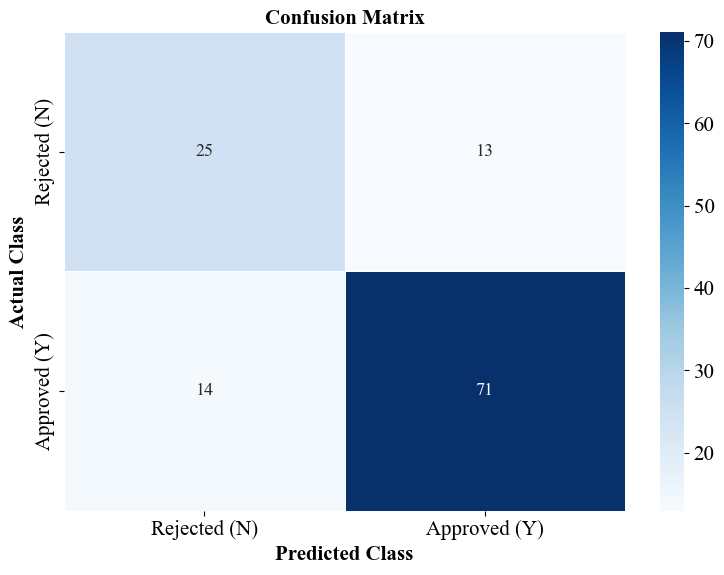

              precision    recall  f1-score   support

Rejected (N)       0.64      0.66      0.65        38
Approved (Y)       0.85      0.84      0.84        85

    accuracy                           0.78       123
   macro avg       0.74      0.75      0.74       123
weighted avg       0.78      0.78      0.78       123



In [9]:
# class_names maps integer labels back to human-readable names
# Order must match the sorted label encoding: [label_for_0, label_for_1]
# e.g. {'N': 0, 'Y': 1}  →  class_names = ["Rejected (N)", "Approved (Y)"]

metrics_df, cm_df, report = classification_metrics(
    y_test       = y_test,
    y_pred       = y_pred,
    y_prob       = y_prob,
    class_names  = ["Rejected (N)", "Approved (Y)"],
    figures_path = FIGURES_PATH,
)

print(report)

## Cell 10 — Save Outputs

In [10]:
import os

os.makedirs(OUTPUT_PATH, exist_ok=True)

# Save the evaluation metrics table
metrics_path = os.path.join(OUTPUT_PATH, "metrics.csv")
metrics_df.to_csv(metrics_path, index=False)
print(f"Saved: {metrics_path}")

# Save the confusion matrix
cm_path = os.path.join(OUTPUT_PATH, "confusion_matrix.csv")
cm_df.to_csv(cm_path)
print(f"Saved: {cm_path}")

# Save the feature importance ranking
scores_path = os.path.join(OUTPUT_PATH, "feature_scores.csv")
scores_df.to_csv(scores_path, index=False)
print(f"Saved: {scores_path}")

print("\nAll outputs saved.")

Saved: d:\Visual_Studio_Code\3122247001061\sem_5\labs\exp_01\output\metrics.csv
Saved: d:\Visual_Studio_Code\3122247001061\sem_5\labs\exp_01\output\confusion_matrix.csv
Saved: d:\Visual_Studio_Code\3122247001061\sem_5\labs\exp_01\output\feature_scores.csv

All outputs saved.


## Student Observations

*Record your observations after running all cells.*

| # | Observation |
|---|-------------|
| 1 | **Dataset**: ___ rows, ___ columns. Target: Loan_Status (Y/N). |
| 2 | **Missing Values**: Columns with missing data — ___. Strategy used: `mean` for numerical, `mode` for categorical. |
| 3 | **Class Imbalance**: Approved (Y): ___%, Rejected (N): ___%. |
| 4 | **Top Features** (Chi-Square): ___ |
| 5 | **Model**: Decision Tree. Accuracy: ___. F1 Score: ___. |
| 6 | **Conclusion**: ___ |